# SHAP Explainability

* **Owner:** Pramodya Dewmi
* **Module:** CCS4310 – Deep Learning
* **Project:** Explainable-Fashion-Design-AI

This notebook explains the predictions of the already-trained market model without retraining it. It loads the saved pipeline, validates the input schema, and computes SHAP-based global and local explanations for a validation/development sample.

Validation workflow:
- load the selected trained model from disk
- load the saved feature config
- validate required feature columns
- compute SHAP importance and local explanation
- save outputs to `outputs/figures` and `outputs/metrics`
- keep the final test split reserved for frozen evaluation

In [1]:
from pathlib import Path
import json
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

RANDOM_STATE = 42

def find_repo_root():
    candidates = [Path.cwd().resolve()]
    candidates.extend(Path.cwd().resolve().parents)
    for p in candidates:
        if (p / 'src').is_dir() and (p / 'data').is_dir() and (p / 'requirements.txt').exists():
            return p
    raise FileNotFoundError('Repository root not found from the current working directory.')

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

INTERIM = ROOT / 'data' / 'interim'
MODEL_ROOT = ROOT / 'models'
METRICS = ROOT / 'outputs' / 'metrics'
FIGURES = ROOT / 'outputs' / 'figures'
for d in [METRICS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

print('Repository root:', ROOT)
print('Using shared repository .venv / selected interpreter:', sys.executable)

from src.explainability.shap_explainer import (
    check_shap_prediction_consistency,
    explain_row,
    global_feature_importance,
    save_global_importance,
)

MODEL_CONFIG_PAIRS = [
    ('demand', MODEL_ROOT / 'demand' / 'best_demand_model.joblib', MODEL_ROOT / 'demand' / 'demand_model_config.json'),
    ('preference', MODEL_ROOT / 'preference' / 'best_customer_preference_model.joblib', MODEL_ROOT / 'preference' / 'customer_preference_model_config.json'),
    ('preference_dev', MODEL_ROOT / 'preference' / 'best_customer_preference_model_dev.joblib', MODEL_ROOT / 'preference' / 'customer_preference_model_config_dev.json'),
]
selected_pair = next(
    ((kind, model_path, config_path) for kind, model_path, config_path in MODEL_CONFIG_PAIRS if model_path.is_file() and config_path.is_file()),
    None,
)
if selected_pair is None:
    MODEL_KIND = None
    MODEL_PATH = None
    CONFIG_PATH = None
else:
    MODEL_KIND, MODEL_PATH, CONFIG_PATH = selected_pair

print('Model path discovered:', MODEL_PATH)
print('Config path discovered:', CONFIG_PATH)

Repository root: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI
Using shared repository .venv / selected interpreter: d:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\.venv\Scripts\python.exe
Model path discovered: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\models\demand\best_demand_model.joblib
Config path discovered: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\models\demand\demand_model_config.json


In [2]:
if MODEL_PATH is None or CONFIG_PATH is None:
    print('No saved trained model/config pair was found in the repository yet. This notebook is intentionally read-only and will skip SHAP execution until the selected pipeline is saved to disk.')
    MODEL_AVAILABLE = False
else:
    pipeline = joblib.load(MODEL_PATH)
    config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
    selected_model = str(config.get('selected_model', '')).strip().lower()
    heuristic_preference_winners = {
        'category preference',
        'global popularity',
        'recent popularity',
    }
    if MODEL_KIND.startswith('preference') and (
        selected_model in heuristic_preference_winners or not hasattr(pipeline, 'named_steps')
    ):
        print('Preference SHAP is unavailable because the selected preference winner is a heuristic baseline.')
        MODEL_AVAILABLE = False
    else:
        MODEL_AVAILABLE = True
        run_type = config.get("run_type", "unknown")
        artifact_suffix = "_dev" if run_type != "full" else ""
        print('Loaded selected model:', config.get('selected_model'))
        print('Model run type:', run_type)
        print('Feature count:', len(config.get('feature_columns', [])))
        
        required_columns = list(config.get('feature_columns', []))
        categorical_features = list(config.get('categorical_features', []))

        if not hasattr(pipeline, 'named_steps'):
            raise TypeError('The saved artifact is not a fitted sklearn Pipeline with prep/model steps; SHAP requires the actual trained pipeline.')

        print('Feature names loaded from config:', required_columns[:10], '...')

Loaded selected model: XGBoost
Model run type: full
Feature count: 17
Feature names loaded from config: ['season', 'season_from_time', 'category', 'color', 'fabric', 'shop_label', 'year', 'month', 'calendar_week', 'day_of_week'] ...


## Validation data and required-feature check

The SHAP development workflow uses the validation/development split and reserves the final test split for the frozen evaluation stage.

In [3]:
def validate_required_features(frame: pd.DataFrame, required_columns: list):
    missing = [col for col in required_columns if col not in frame.columns]
    if missing:
        raise ValueError(f'Missing required model features: {missing}')
    return True

if MODEL_AVAILABLE:
    validation_path = INTERIM / 'visuelle_demand_validation.csv'
    if validation_path.is_file():
        validation_df = pd.read_csv(validation_path, parse_dates=['time'])
        validate_required_features(validation_df, required_columns)
        sample_size = min(5000, len(validation_df))
        explain_df = validation_df.sample(n=sample_size, random_state=RANDOM_STATE).reset_index(drop=True)
        X_explain = explain_df[required_columns]
        print('Validation rows loaded:', len(explain_df))
        print('Required features validated successfully.')
    else:
        print('Validation data not found at', validation_path, '. This notebook will skip full SHAP execution until the expected validation split is present.')
        explain_df = pd.DataFrame()
        X_explain = pd.DataFrame()

Validation rows loaded: 5000
Required features validated successfully.


In [4]:
if MODEL_AVAILABLE and not X_explain.empty:
    consistency_results = [
        check_shap_prediction_consistency(pipeline, X_explain, row_index=row_index, tolerance=1e-3)
        for row_index in range(min(5, len(X_explain)))
    ]
    for row_index, consistency in enumerate(consistency_results):
        print(f'Row {row_index} actual prediction:', consistency['actual_prediction'])
        print(f'Row {row_index} SHAP reconstructed prediction:', consistency['reconstructed_prediction'])
        print(f'Row {row_index} absolute difference:', consistency['difference'])
        print(f"Row {row_index} consistency status:", 'consistent' if consistency['consistent'] else 'mismatch')
        print(consistency['message'])
    if any(not consistency['consistent'] for consistency in consistency_results):
        raise RuntimeError(
            "SHAP consistency validation failed. SHAP artifacts will not be generated."
        )
else:
    print('Skipping SHAP consistency verification because the trained pipeline is unavailable.')

Row 0 actual prediction: 2.971026659011841
Row 0 SHAP reconstructed prediction: 2.9710248953570044
Row 0 absolute difference: 1.7636548363952897e-06
Row 0 consistency status: consistent
SHAP reconstruction is consistent within tolerance.
Row 1 actual prediction: 0.8322713375091553
Row 1 SHAP reconstructed prediction: 0.8322714255948469
Row 1 absolute difference: 8.808569162965796e-08
Row 1 consistency status: consistent
SHAP reconstruction is consistent within tolerance.
Row 2 actual prediction: 0.8258693814277649
Row 2 SHAP reconstructed prediction: 0.8258693006318651
Row 2 absolute difference: 8.079589974840928e-08
Row 2 consistency status: consistent
SHAP reconstruction is consistent within tolerance.
Row 3 actual prediction: 0.0803646594285965
Row 3 SHAP reconstructed prediction: 0.08036471880602392
Row 3 absolute difference: 5.937742741934926e-08
Row 3 consistency status: consistent
SHAP reconstruction is consistent within tolerance.
Row 4 actual prediction: 1.0274780988693237
Row

## Global SHAP feature importance

This section computes the global mean absolute SHAP importance for the validation sample and saves the metric CSV plus the bar-chart figure.

In [5]:
if MODEL_AVAILABLE and not X_explain.empty:
    shap_importance = save_global_importance(
        pipeline,
        X_explain,
        metrics_path=METRICS / f'dewmi_shap_global_importance{artifact_suffix}.csv',
        figures_path=FIGURES / f'dewmi_shap_global_importance{artifact_suffix}.png',
        top_n=20,
    )
    display(shap_importance.head(15))
    print('Global SHAP metrics saved to:', METRICS / f'dewmi_shap_global_importance{artifact_suffix}.csv')
    print('Global SHAP figure saved to:', FIGURES / f'dewmi_shap_global_importance{artifact_suffix}.png')
else:
    print('Skipping global SHAP computation because the saved model or validation data is unavailable.')

,mean_abs_shap
num__demand_rolling_mean_3,0.256211
num__demand_lag_1,0.180291
num__restock_past_1,0.174131
num__calendar_week,0.060348
num__demand_lag_3,0.042626
num__discount_past_1,0.037972
num__demand_rolling_std_3,0.037276
cat__fabric_georgette,0.020702
cat__season_from_time_summer,0.019190
cat__shop_label_12,0.018324


Global SHAP metrics saved to: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\outputs\metrics\dewmi_shap_global_importance.csv
Global SHAP figure saved to: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\outputs\figures\dewmi_shap_global_importance.png


## Local SHAP explanation and feature ranking

A single-row local explanation identifies the positive and negative factors for one representative design.

Base value: 1.283
Predicted value: 2.971
Top positive contributors:


,feature,shap_value
0,cat__shop_label_12,0.648389
1,num__demand_rolling_mean_3,0.595305
2,cat__category_long dress,0.278151
3,num__demand_rolling_std_3,0.169658
4,num__demand_lag_1,0.145941


Top negative contributors:


,feature,shap_value
0,num__restock_past_1,-0.086785
1,num__calendar_week,-0.056567
2,cat__color_yellow,-0.025737
3,cat__color_black,-0.021921
4,cat__fabric_georgette,-0.020316


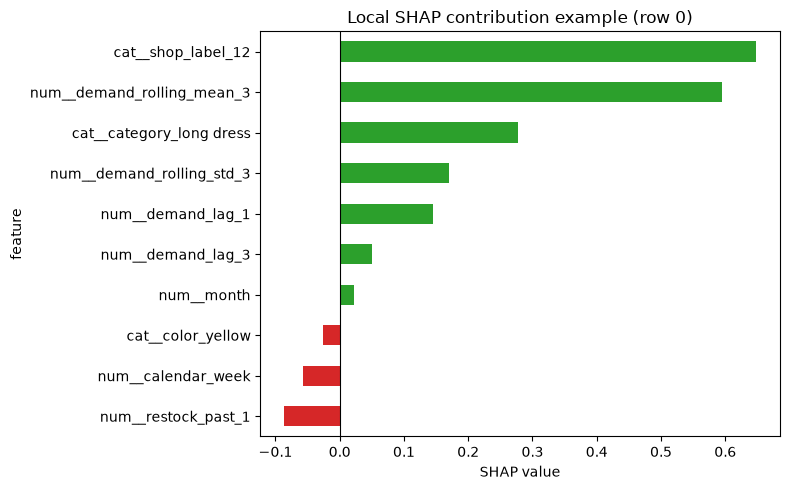

,attribute,current_value,shap_value
0,color,yellow,-0.025737
1,season_from_time,spring,-0.005110
2,fabric,tulle,0.000681
3,season,SS19,0.011810
4,category,long dress,0.278151
5,shop_label,12,0.648389


In [6]:
if MODEL_AVAILABLE and not X_explain.empty:
    example_index = 0
    explanation = explain_row(pipeline, X_explain, row_index=example_index)
    print('Base value:', round(explanation.base_value, 4))
    print('Predicted value:', round(explanation.predicted_value, 4))
    print('Top positive contributors:')
    display(explanation.top_contributions(n=5, direction='positive'))
    print('Top negative contributors:')
    display(explanation.top_contributions(n=5, direction='negative'))
    
    local_df = explanation.top_contributions(n=10, direction='both').copy()
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_df = local_df.set_index('feature')['shap_value'].sort_values()
    colors = ['#d62728' if v < 0 else '#2ca02c' for v in plot_df.values]
    plot_df.plot.barh(ax=ax, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value')
    ax.set_title(f'Local SHAP contribution example (row {example_index})')
    fig.tight_layout()
    fig.savefig(FIGURES / f'dewmi_shap_local_example{artifact_suffix}.png', dpi=150)
    plt.show()
    
    attribute_view = explanation.attribute_contributions(categorical_features)
    display(attribute_view.head(10))
else:
    print('Skipping local SHAP explanation because the model or validation data is unavailable.')

## SHAP prediction consistency check

This is a required guardrail: the pipeline prediction and the SHAP reconstruction must agree within a reasonable tolerance. This catches the 5.880-vs-1.668 mismatch pattern instead of silently accepting it.